<h1>        ONLINE COURSE STUDENT ENAGEMENT PERFORMANCE ANALYSIS USING                SQL+PYTHON</h1>

## 🎯Project Objective

To analyze student engagement and academic performance using SQL and Python,
and identify patterns related to study hours, attendance, scores,
completion status, and course ratings.

## 🔎Business Questions

1.What is the total number of enrolled students?

2.How many students are enrolled in each course?

3.Which course has the highest average Final Score?

4.Which course has the highest average Attendance?

5.What is the average Study Hours for each course?

6.What is the completion-status distribution?

7.Which course has the highest number of dropped students?

8.Which course has the highest average Course Rating?

9.Who are the top 10 students based on Final Score?

10.How does student performance differ by Gender?

11.Does higher Attendance lead to higher Final Score?

12.Does Study Hours influence Final Score?

13.Which month has the highest number of enrollments?

14.Which students have low Final Scores but high Study Hours?

15.Which course shows the best overall student performance?


                        ----Before builiding a SQL project we have to clean and understanding data using python---


## 1.Load the Dataset

In [12]:

import pandas as pd

df = pd.read_excel(r"C:\Users\reena\Downloads\IMARTICUS\PERSONAL PROJECTS\SQL\Online_Course_Student_Engagement_Dataset.xlsx")

print(df.head())

  Student_ID       Course_Name  Age  Gender Enrollment_Date  Study_Hours  \
0    STU1001        Statistics   25  Female      2025-03-12         23.6   
1    STU1002  Machine Learning   30    Male      2025-12-30         16.3   
2    STU1003             Excel   36  Female      2025-02-27         19.1   
3    STU1004        Statistics   20  Female      2025-10-17         20.5   
4    STU1005    Data Analytics   25    Male      2025-09-08         21.4   

   Attendance  Assignment_Score  Quiz_Score  Final_Score Completion_Status  \
0        89.3              92.5        80.8         89.3         Completed   
1        61.1              88.0        43.5         61.8         Completed   
2        65.3              96.2        95.7         86.3         Completed   
3        94.7              58.5        53.4         66.6           Dropped   
4        55.9              76.7       100.0         76.0         Completed   

   Course_Rating  
0            5.0  
1            2.6  
2            3.6 

## 2.Understanding the Data

In [11]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (2000, 12)

Column Names:
['Student_ID', 'Course_Name', 'Age', 'Gender', 'Enrollment_Date', 'Study_Hours', 'Attendance', 'Assignment_Score', 'Quiz_Score', 'Final_Score', 'Completion_Status', 'Course_Rating']

Data Types:
Student_ID                   object
Course_Name                  object
Age                           int64
Gender                       object
Enrollment_Date      datetime64[ns]
Study_Hours                 float64
Attendance                  float64
Assignment_Score            float64
Quiz_Score                  float64
Final_Score                 float64
Completion_Status            object
Course_Rating               float64
dtype: object

Missing Values:
Student_ID           0
Course_Name          0
Age                  0
Gender               0
Enrollment_Date      0
Study_Hours          0
Attendance           0
Assignment_Score     0
Quiz_Score           0
Final_Score          0
Completion_Status    0
Course_Rating        0
dtype: int64

Duplicate R

## 3.Data Cleaning and Validation

In [5]:
# Check unique values in categorical columns

print("Course Names:")
print(df["Course_Name"].unique())

print("\nGender:")
print(df["Gender"].unique())

print("\nCompletion Status:")
print(df["Completion_Status"].unique())

Course Names:
['Statistics' 'Machine Learning' 'Excel' 'Data Analytics' 'SQL' 'Power BI'
 'Python']

Gender:
['Female' 'Male']

Completion Status:
['Completed' 'Dropped' 'In Progress']


In [6]:
# Check range in numerical columns

print("\nAge Range:")
print(df["Age"].min(), "to", df["Age"].max())

print("\nAttendance Range:")
print(df["Attendance"].min(), "to", df["Attendance"].max())

print("\nCourse Rating Range:")
print(df["Course_Rating"].min(), "to", df["Course_Rating"].max())


Age Range:
18 to 40

Attendance Range:
55.0 to 100.0

Course Rating Range:
2.5 to 5.0


## 4. Data validation

In [19]:
# Check numerical ranges

print("Age Range:", df["Age"].min(), "to", df["Age"].max())
print("Attendance Range:", df["Attendance"].min(), "to", df["Attendance"].max())
print("Assignment Score Range:", df["Assignment_Score"].min(), "to", df["Assignment_Score"].max())
print("Quiz Score Range:", df["Quiz_Score"].min(), "to", df["Quiz_Score"].max())
print("Final Score Range:", df["Final_Score"].min(), "to", df["Final_Score"].max())
print("Course Rating Range:", df["Course_Rating"].min(), "to", df["Course_Rating"].max())

Age Range: 18 to 40
Attendance Range: 55.0 to 100.0
Assignment Score Range: 45.0 to 100.0
Quiz Score Range: 40.0 to 100.0
Final Score Range: 36.7 to 99.9
Course Rating Range: 2.5 to 5.0


## 5.SQL Setup

In [7]:
# Save dataset as CSV for SQL import
df.to_csv("online_course_students.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


## 6.File Path

In [8]:
import os

print(os.getcwd())

C:\Users\reena


In [9]:
df.to_csv("online_course_students.csv", index=False)
print("CSV saved at:", os.path.abspath("online_course_students.csv"))

CSV saved at: C:\Users\reena\online_course_students.csv


## 7. EDA

In [13]:
print("Course Names:")
print(df["Course_Name"].value_counts())

print("\nCompletion Status:")
print(df["Completion_Status"].value_counts())

print("\nGender:")
print(df["Gender"].value_counts())

Course Names:
Course_Name
Python              307
Excel               295
SQL                 282
Statistics          281
Power BI            280
Data Analytics      279
Machine Learning    276
Name: count, dtype: int64

Completion Status:
Completion_Status
Completed      1128
In Progress     552
Dropped         320
Name: count, dtype: int64

Gender:
Gender
Female    1020
Male       980
Name: count, dtype: int64


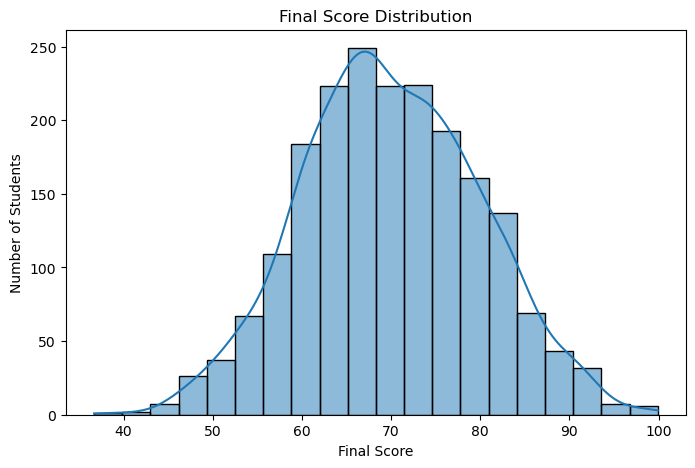

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["Final_Score"], bins=20, kde=True)
plt.title("Final Score Distribution")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.show()

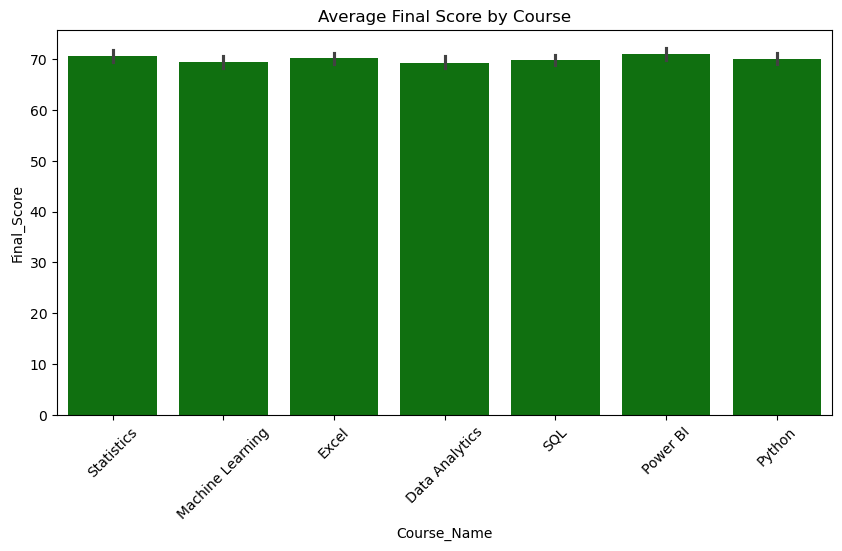

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Course_Name", y="Final_Score", estimator="mean",color="Green")
plt.xticks(rotation=45)
plt.title("Average Final Score by Course")
plt.show()

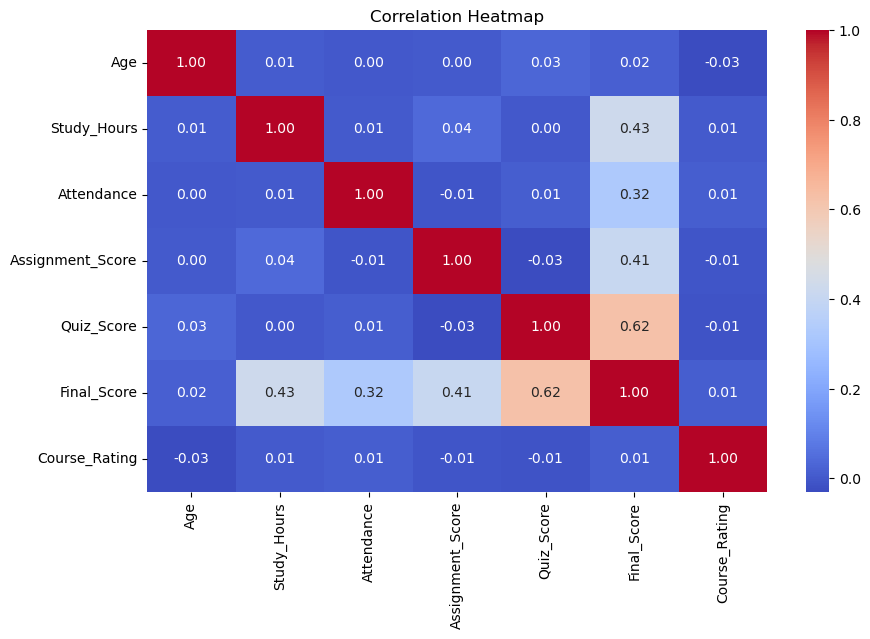

In [18]:
numeric_cols = [
    "Age",
    "Study_Hours",
    "Attendance",
    "Assignment_Score",
    "Quiz_Score",
    "Final_Score",
    "Course_Rating"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 8.Conclusion



1.This project analyzed **Online Course Student Engagement and Performance** using SQL and Python. The analysis covered student enrollment, course-wise participation, study hours, attendance, academic scores, completion status, and course ratings.

2.The SQL analysis helped identify the **most popular courses, best-performing courses, attendance patterns, completion and dropout trends, top-performing students, and monthly enrollment patterns**. It also showed how **study hours and attendance are associated with students’ final performance**.

3.Overall, the project provides useful insights into student behavior and course performance. These insights can help educational platforms **identify struggling students, improve course quality, reduce dropout rates, and support better learning outcomes**.

4.The project demonstrates how **SQL can be used to extract meaningful business insights from real-world student data**, while Python can be used for further analysis and visualization.
